# Stage 02 — 2.5D PET/CT Retrieval Baseline  
## Google Colab Complete Edition — Exact Full-Report Metrics

**Stage 01 output source**

`dngtrnphmtunse183674/00-01-cache-streaming`

**Stage 02 source notebook**

`tundng111/02-2-5d-pet-ct-retrieval-baseline`

Notebook này chạy trực tiếp trên **Google Colab**, không dùng `/kaggle/input`.

### Output chính

- `reports_by_case_id.csv` và `.parquet`
- `retrieval_detail_exact.csv` và `.parquet`
- `validation_topk_retrieved_exact.csv` và `.parquet`
- `test_topk_retrieved_exact.csv` và `.parquet`
- `retrieval_metrics.json`
- `retrieval_metrics_summary.csv`
- `stage02_exact_dashboard.png`
- embeddings và FAISS index
- ZIP tổng hợp

BLEU/ROUGE được tính từ **toàn bộ `query_report` và `retrieved_report`**, không dùng preview.

In [1]:
# CELL 1 — Install dependencies for Colab

import os
import sys
import subprocess

os.environ.setdefault(
    "PYTORCH_CUDA_ALLOC_CONF",
    "expandable_segments:True"
)

packages = [
    "kagglehub>=0.3.10",
    "faiss-cpu",
    "scikit-learn>=1.4.0",
    "sentence-transformers>=3.0.0",
    "nltk",
    "rouge-score",
    "pyarrow",
    "bert-score",
]

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--no-cache-dir",
    *packages,
])

print("✅ Dependencies installed.")

✅ Dependencies installed.


In [2]:
# CELL 2 — Imports, reproducibility and paths

import gc
import json
import math
import random
import re
import time
import hashlib
import shutil
from pathlib import Path
from typing import Any, Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
from IPython.display import display

try:
    import torch
except Exception:
    torch = None

SEED = 391
random.seed(SEED)
np.random.seed(SEED)

if torch is not None:
    torch.manual_seed(SEED)

STAGE1_HANDLE = (
    "dngtrnphmtunse183674/"
    "00-01-cache-streaming"
)

STAGE2_SOURCE_HANDLE = (
    "tundng111/"
    "02-2-5d-pet-ct-retrieval-baseline"
)

# Khuyên dùng Drive vì Stage 01 có file memmap lớn.
USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_ROOT = Path(
        "/content/drive/MyDrive/ViMedPET_Colab"
    )
else:
    PROJECT_ROOT = Path("/content/ViMedPET_Colab")

STAGE1_ROOT = PROJECT_ROOT / "stage01_output"
STAGE2_ROOT = PROJECT_ROOT / "stage02_output"

OUTPUT_ROOT = (
    STAGE2_ROOT
    / "vimedpet_stage02_retrieval_outputs"
)

TABLE_DIR = OUTPUT_ROOT / "tables"
EMB_DIR = OUTPUT_ROOT / "embeddings"
INDEX_DIR = OUTPUT_ROOT / "indices"

for path in [
    PROJECT_ROOT,
    STAGE1_ROOT,
    STAGE2_ROOT,
    OUTPUT_ROOT,
    TABLE_DIR,
    EMB_DIR,
    INDEX_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

TOP_K = 10
BATCH_SIZE_IMAGE = 128
BATCH_SIZE_TEXT = 32

TEXT_MODEL_CANDIDATES = [
    "sentence-transformers/"
    "paraphrase-multilingual-MiniLM-L12-v2",
    "sentence-transformers/"
    "distiluse-base-multilingual-cased-v2",
]

CLINICAL_KEYWORDS = [
    "hạch", "phổi", "xương", "thận", "gan",
    "cổ", "chậu", "đại tràng", "ổ bụng",
    "lách", "não", "amydal", "trung thất",
    "tuyến giáp", "dạ dày", "vú",
    "thượng đòn", "vòm", "tụy",
    "tuyến tiền liệt",
]

print("Stage 01:", STAGE1_HANDLE)
print("Stage 02 source:", STAGE2_SOURCE_HANDLE)
print("Project root:", PROJECT_ROOT)
print("Output root:", OUTPUT_ROOT)

if torch is not None:
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
Stage 01: dngtrnphmtunse183674/00-01-cache-streaming
Stage 02 source: tundng111/02-2-5d-pet-ct-retrieval-baseline
Project root: /content/drive/MyDrive/ViMedPET_Colab
Output root: /content/drive/MyDrive/ViMedPET_Colab/stage02_output/vimedpet_stage02_retrieval_outputs
CUDA available: True
GPU: Tesla T4


In [3]:
# CELL 3 — Authenticate KaggleHub safely

import os
from getpass import getpass

token = None

try:
    from google.colab import userdata
    token = userdata.get("KAGGLE_API_TOKEN")
except Exception:
    token = None

if not token:
    token = getpass(
        "Dán Kaggle API Token KGAT_... "
        "(ký tự được ẩn): "
    ).strip()

if not token:
    raise ValueError(
        "Chưa có KAGGLE_API_TOKEN."
    )

os.environ["KAGGLE_API_TOKEN"] = token

print("✅ KaggleHub authentication ready.")

Dán Kaggle API Token KGAT_... (ký tự được ẩn): ··········
✅ KaggleHub authentication ready.


In [4]:
# CELL 4 — Download or reuse Stage 01 notebook output

import kagglehub

REQUIRED_STAGE1_FILES = [
    "q1_cache_meta.json",
    "q1_cache_index.csv",
    "q1_clean_manifest_for_cache.csv",
    "q1_25d_uint8_224.memmap",
]

def locate_file(
    filename: str,
    roots: List[Path]
) -> Path | None:
    matches = []

    for root in roots:
        if not root.exists():
            continue

        direct = root / filename
        if direct.exists():
            matches.append(direct)

        matches.extend(root.rglob(filename))

    if not matches:
        return None

    return sorted(
        set(matches),
        key=lambda p: (
            len(str(p)),
            str(p)
        )
    )[0]

def stage1_files_present() -> Dict[str, Path]:
    found = {}

    for filename in REQUIRED_STAGE1_FILES:
        path = locate_file(
            filename,
            [STAGE1_ROOT]
        )

        if path is not None:
            found[filename] = path

    return found

found_before = stage1_files_present()

if len(found_before) == len(REQUIRED_STAGE1_FILES):
    print("✅ Reusing existing Stage 01 output.")
else:
    print(
        "Stage 01 cache is incomplete locally. "
        "Downloading Kaggle notebook output..."
    )

    result = kagglehub.notebook_output_download(
        STAGE1_HANDLE,
        output_dir=str(STAGE1_ROOT),
    )

    print("Download result:", result)

found_stage1 = stage1_files_present()

print("\n===== STAGE 01 FILE CHECK =====")

for filename in REQUIRED_STAGE1_FILES:
    path = found_stage1.get(filename)

    if path is None:
        print(f"❌ {filename}: missing")
    else:
        size_gb = path.stat().st_size / (1024 ** 3)

        print(
            f"✅ {filename}\n"
            f"   {path}\n"
            f"   {size_gb:.3f} GB"
        )

missing_stage1 = [
    name
    for name in REQUIRED_STAGE1_FILES
    if name not in found_stage1
]

if missing_stage1:
    raise FileNotFoundError(
        "Stage 01 output thiếu: "
        + ", ".join(missing_stage1)
        + ". Hãy kiểm tra Stage 01 đã Save Version "
        "và các file nằm trong notebook output."
    )

cache_meta_path = found_stage1[
    "q1_cache_meta.json"
]
cache_index_path = found_stage1[
    "q1_cache_index.csv"
]
manifest_path = found_stage1[
    "q1_clean_manifest_for_cache.csv"
]
memmap_path = found_stage1[
    "q1_25d_uint8_224.memmap"
]

print("\n✅ Stage 01 is ready.")

✅ Reusing existing Stage 01 output.

===== STAGE 01 FILE CHECK =====
✅ q1_cache_meta.json
   /content/drive/MyDrive/ViMedPET_Colab/stage01_output/vimedpet_q1_outputs/01_cache/q1_cache_meta.json
   0.000 GB
✅ q1_cache_index.csv
   /content/drive/MyDrive/ViMedPET_Colab/stage01_output/vimedpet_q1_outputs/01_cache/q1_cache_index.csv
   0.001 GB
✅ q1_clean_manifest_for_cache.csv
   /content/drive/MyDrive/ViMedPET_Colab/stage01_output/vimedpet_q1_outputs/01_cache/q1_clean_manifest_for_cache.csv
   0.012 GB
✅ q1_25d_uint8_224.memmap
   /content/drive/MyDrive/ViMedPET_Colab/stage01_output/vimedpet_q1_outputs/01_cache/q1_25d_uint8_224.memmap
   0.387 GB

✅ Stage 01 is ready.


In [5]:
# CELL 5 — Read Stage 01 metadata and verify cache integrity

meta = json.loads(
    cache_meta_path.read_text(
        encoding="utf-8"
    )
)

shape_meta = meta.get("shape")

if not (
    isinstance(shape_meta, list)
    and len(shape_meta) == 4
):
    raise ValueError(
        f"Invalid cache shape: {shape_meta}"
    )

n_cases, channels, image_h, image_w = map(
    int,
    shape_meta
)

dtype_name = str(
    meta.get("dtype", "uint8")
)
dtype = np.dtype(dtype_name)

expected_bytes = (
    n_cases
    * channels
    * image_h
    * image_w
    * dtype.itemsize
)

actual_bytes = memmap_path.stat().st_size

print(json.dumps(
    meta,
    ensure_ascii=False,
    indent=2
))

print("Expected memmap bytes:", expected_bytes)
print("Actual memmap bytes:", actual_bytes)

if actual_bytes != expected_bytes:
    raise ValueError(
        "Memmap size mismatch: "
        f"{actual_bytes} vs {expected_bytes}"
    )

print("✅ Memmap size matches metadata.")

{
  "stage": "01_build_25d_cache_streaming",
  "stage00_manifest_path": "/kaggle/working/vimedpet_q1_outputs/00_manifest/q1_clean_manifest_for_cache.csv",
  "cache_path": "/kaggle/working/vimedpet_q1_outputs/01_cache/q1_25d_uint8_224.memmap",
  "cache_index_path": "/kaggle/working/vimedpet_q1_outputs/01_cache/q1_cache_index.csv",
  "cache_manifest_path": "/kaggle/working/vimedpet_q1_outputs/01_cache/q1_clean_manifest_for_cache.csv",
  "cache_error_path": "/kaggle/working/vimedpet_q1_outputs/01_cache/q1_cache_errors.csv",
  "n_cases_manifest": 2757,
  "n_cache_rows": 2757,
  "ok_rows": 2757,
  "error_rows": 0,
  "status_counts": {
    "ok": 2757
  },
  "shape": [
    2757,
    3,
    224,
    224
  ],
  "dtype": "uint8",
  "image_size": 224,
  "channels": [
    "ct_central_slice",
    "pet_mip",
    "ct_pet_overlay_proxy"
  ],
  "normalization": {
    "ct": "per-volume robust percentile 1-99 on central slice",
    "pet": "per-volume robust percentile 1-99.5 then axial MIP",
    "overlay

In [6]:
# CELL 6 — Load manifest, join cache index and precheck PM Gate

manifest = pd.read_csv(manifest_path)
cache_index = pd.read_csv(cache_index_path)

if "cache_ok" not in cache_index.columns:
    if "status" in cache_index.columns:
        cache_index["cache_ok"] = (
            cache_index["status"]
            .astype(str)
            .str.lower()
            .eq("ok")
        )
    else:
        cache_index["cache_ok"] = True
else:
    cache_index["cache_ok"] = (
        cache_index["cache_ok"]
        .astype(str)
        .str.lower()
        .isin(["true", "1", "yes", "ok"])
    )

has_row_index_both = (
    {"case_id", "row_index"}
    .issubset(manifest.columns)
    and
    {"case_id", "row_index"}
    .issubset(cache_index.columns)
)

join_cols = (
    ["case_id", "row_index"]
    if has_row_index_both
    else ["case_id"]
)

cache_cols = [
    col
    for col in [
        "case_id",
        "row_index",
        "cache_ok",
        "status",
        "cache_error",
        "ct_shape",
        "pet_shape",
    ]
    if col in cache_index.columns
]

df = manifest.merge(
    cache_index[cache_cols],
    on=join_cols,
    how="inner",
    suffixes=("", "_cache"),
)

target_col = next(
    (
        col
        for col in [
            "model_target_text",
            "report_text_clean",
            "target_text",
            "report_text",
        ]
        if col in df.columns
    ),
    None,
)

if target_col is None:
    raise KeyError(
        "Không tìm thấy full report column. "
        f"Columns: {df.columns.tolist()}"
    )

df[target_col] = (
    df[target_col]
    .fillna("")
    .astype(str)
)

df = df[
    (df["cache_ok"] == True)
    & (df[target_col].str.len() > 10)
].copy()

split_col = (
    "clean_split"
    if "clean_split" in df.columns
    else "split"
)

if split_col not in df.columns:
    raise KeyError("Missing split column.")

expected_rows = int(
    meta.get("ok_rows")
    or meta.get("n_cache_rows")
    or meta.get("n_cases_manifest")
    or len(manifest)
)

if len(df) != expected_rows:
    raise ValueError(
        "Rows mismatch after join/filter: "
        f"{len(df)} vs {expected_rows}"
    )

if not (
    n_cases == expected_rows == len(df)
):
    raise ValueError(
        "Cache/manifest row mismatch: "
        f"n_cases={n_cases}, "
        f"expected={expected_rows}, "
        f"joined={len(df)}"
    )

if channels != 3:
    raise ValueError(
        f"Expected 3 channels, got {channels}"
    )

# Normalize split labels.
df[split_col] = (
    df[split_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "val": "validation",
        "valid": "validation",
    })
)

required_splits = {
    "train",
    "validation",
    "test",
}

available_splits = set(
    df[split_col].unique()
)

missing_splits = (
    required_splits - available_splits
)

if missing_splits:
    raise ValueError(
        "Missing split(s): "
        + ", ".join(sorted(missing_splits))
    )

train_df = (
    df[df[split_col] == "train"]
    .reset_index(drop=True)
)
val_df = (
    df[df[split_col] == "validation"]
    .reset_index(drop=True)
)
test_df = (
    df[df[split_col] == "test"]
    .reset_index(drop=True)
)

stage01_pass = (
    str(meta.get("pm_gate", "")).upper()
    == "PASS"
    and int(meta.get("error_rows", 0)) == 0
)

print("Stage 01 PM Gate PASS:", stage01_pass)
print(
    "train/validation/test:",
    len(train_df),
    len(val_df),
    len(test_df),
)
print("Full report column:", target_col)

display(df.head(2))

Stage 01 PM Gate PASS: True
train/validation/test: 1930 414 413
Full report column: report_text_clean


,source_part,patient_key,month,day,ct_path,pet_path,report_path,n_ct_candidates,n_pet_candidates,n_report_candidates,...,usable_for_generation,usable_for_training,stable_patient_group,clean_split,suv_mention_count,row_index,cache_ok,status,ct_shape,pet_shape
0,PETCT_2017,0,8,1,PETCT_2017/THANG 8/CT/day_1_patient_0.npy,PETCT_2017/THANG 8/PET/day_1_patient_0.npy,PETCT_2017/THANG 8/reports/day_1_patient_0.json,1,1,1,...,True,True,PETCT_2017::0,validation,0,0,True,ok,"(313, 512, 512)","(313, 256, 256)"
1,PETCT_2017,1,8,1,PETCT_2017/THANG 8/CT/day_1_patient_1.npy,PETCT_2017/THANG 8/PET/day_1_patient_1.npy,PETCT_2017/THANG 8/reports/day_1_patient_1.json,1,1,1,...,True,True,PETCT_2017::1,train,10,1,True,ok,"(313, 512, 512)","(313, 256, 256)"


In [7]:
# CELL 7 — Split, section, source, SUV/FDG, keyword, duplicate audits

def norm_text(x: Any) -> str:
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return ""
    return re.sub(r"\s+", " ", str(x).replace("\u00a0", " ")).strip()

def has_text_col(col: str) -> pd.Series:
    if col not in df.columns:
        return pd.Series(False, index=df.index)
    return df[col].fillna("").astype(str).str.strip().str.len() > 0

patient_group_col = next(
    (
        c for c in [
            "stable_patient_group",
            "patient_key",
            "patient_id",
            "case_id",
        ]
        if c in df.columns
    ),
    "case_id",
)
splits = ["train", "validation", "test"]

split_count_by_case = df.groupby(split_col).size().reindex(splits, fill_value=0).reset_index(name="n_cases")
split_count_by_case.to_csv(TABLE_DIR / "split_count_by_case.csv", index=False, encoding="utf-8-sig")
display(split_count_by_case)

split_count_by_patient = df.groupby(split_col)[patient_group_col].nunique().reindex(splits, fill_value=0).reset_index(name="n_patient_groups")
split_count_by_patient.to_csv(TABLE_DIR / "split_count_by_patient_group.csv", index=False, encoding="utf-8-sig")
display(split_count_by_patient)

sets = {s: set(df.loc[df[split_col] == s, patient_group_col].astype(str)) for s in splits}
overlap = pd.DataFrame([[len(sets[a] & sets[b]) for b in splits] for a in splits], index=splits, columns=splits)
overlap.to_csv(TABLE_DIR / "patient_overlap_matrix.csv", encoding="utf-8-sig")
display(overlap)

if "source_part" not in df.columns:
    df["source_part"] = "unknown"

source_part_by_split = pd.crosstab(
    df[split_col],
    df["source_part"],
    margins=True
)
source_part_by_split.to_csv(TABLE_DIR / "source_part_by_split.csv", encoding="utf-8-sig")
display(source_part_by_split)

if "report_word_count" not in df.columns:
    df["report_word_count"] = df[target_col].map(lambda x: len(norm_text(x).split()))
report_word_count_by_split = df.groupby(split_col)["report_word_count"].describe().reset_index()
report_word_count_by_split.to_csv(TABLE_DIR / "report_word_count_by_split.csv", index=False, encoding="utf-8-sig")
display(report_word_count_by_split)

section_rows = []
for s in splits:
    sub = df[df[split_col] == s]
    section_rows.append({
        "split": s,
        "n": len(sub),
        "has_findings": int(sub["has_findings"].sum()) if "has_findings" in sub.columns else int(has_text_col("findings").loc[sub.index].sum()),
        "has_impression": int(sub["has_impression"].sum()) if "has_impression" in sub.columns else int(has_text_col("impression").loc[sub.index].sum()),
    })
section_completeness = pd.DataFrame(section_rows)
section_completeness["findings_missing"] = section_completeness["n"] - section_completeness["has_findings"]
section_completeness["impression_missing"] = section_completeness["n"] - section_completeness["has_impression"]
section_completeness.to_csv(TABLE_DIR / "section_completeness_by_split.csv", index=False, encoding="utf-8-sig")
display(section_completeness)

suv_pat = re.compile(r"\bSUV(?:max)?\s*[:=]?\s*(\d+(?:[\.,]\d+)?)", flags=re.IGNORECASE)
def suv_values(text: str) -> List[float]:
    vals = []
    for m in suv_pat.finditer(norm_text(text)):
        try:
            vals.append(float(m.group(1).replace(",", ".")))
        except Exception:
            pass
    return vals

suv_rows = []
for _, r in df.iterrows():
    vals = suv_values(r[target_col])
    suv_rows.append({
        "case_id": r["case_id"],
        "split": r[split_col],
        "source_part": r.get("source_part", "unknown"),
        "suv_count": len(vals),
        "suv_max": max(vals) if vals else np.nan,
        "has_fdg": "fdg" in norm_text(r[target_col]).lower(),
    })
suv_case = pd.DataFrame(suv_rows)
suv_fdg_by_split_source = suv_case.groupby(["split", "source_part"]).agg(
    n_cases=("case_id", "count"), reports_with_suv=("suv_count", lambda x: int((x > 0).sum())),
    suv_values=("suv_count", "sum"), suv_case_max=("suv_max", "max"), reports_with_fdg=("has_fdg", "sum")
).reset_index()
suv_fdg_by_split_source.to_csv(TABLE_DIR / "suv_fdg_by_split_source.csv", index=False, encoding="utf-8-sig")
display(suv_fdg_by_split_source)

keyword_rows = []
for s in splits:
    sub_text = " ".join(df.loc[df[split_col] == s, target_col].map(norm_text).tolist()).lower()
    for kw in CLINICAL_KEYWORDS:
        keyword_rows.append({"split": s, "keyword": kw, "count": sub_text.count(kw.lower())})
clinical_keyword_by_split = pd.DataFrame(keyword_rows)
clinical_keyword_by_split.to_csv(TABLE_DIR / "clinical_keyword_by_split.csv", index=False, encoding="utf-8-sig")
display(clinical_keyword_by_split.head(30))

dup = df[["case_id", split_col, "source_part", target_col]].copy()
dup["report_hash"] = dup[target_col].map(lambda x: hashlib.sha1(norm_text(x).lower().encode("utf-8")).hexdigest())
dup_counts = dup.groupby("report_hash").agg(n=("case_id", "count"), splits=(split_col, lambda x: ",".join(sorted(set(map(str, x))))), case_ids=("case_id", lambda x: ",".join(map(str, list(x)[:10])))).reset_index()
duplicate_report_hash_audit = dup_counts[dup_counts["n"] > 1].sort_values("n", ascending=False)
duplicate_report_hash_audit.to_csv(TABLE_DIR / "duplicate_report_hash_audit.csv", index=False, encoding="utf-8-sig")
print("duplicate report hashes:", len(duplicate_report_hash_audit))
display(duplicate_report_hash_audit.head(10))

,clean_split,n_cases
0,train,1930
1,validation,414
2,test,413


,clean_split,n_patient_groups
0,train,1900
1,validation,414
2,test,413


,train,validation,test
train,1900,0,0
validation,0,414,0
test,0,0,413


source_part,PETCT_2017,PETCT_2018,PETCT_2019,PETCT_2023_1,PETCT_2023_2,PETCT_2023_3,All
clean_split,,,,,,,
test,26,79,47,77,102,82,413
train,155,320,247,344,550,314,1930
validation,34,63,45,81,110,81,414
All,215,462,339,502,762,477,2757


,clean_split,count,mean,std,min,25%,50%,75%,max
0,test,413.0,377.196126,57.359434,218.0,333.00,375.0,421.00,559.0
1,train,1930.0,379.502591,60.045742,218.0,339.00,379.0,419.75,615.0
2,validation,414.0,384.497585,60.376051,59.0,347.25,381.0,420.00,569.0


,split,n,has_findings,has_impression,findings_missing,impression_missing
0,train,1930,1930,1910,0,20
1,validation,414,413,410,1,4
2,test,413,413,410,0,3


,split,source_part,n_cases,reports_with_suv,suv_values,suv_case_max,reports_with_fdg
0,test,PETCT_2017,26,25,76,32.0,26
1,test,PETCT_2018,79,59,188,33.0,79
2,test,PETCT_2019,47,43,132,18.9,47
3,test,PETCT_2023_1,77,72,274,46.6,77
4,test,PETCT_2023_2,102,95,266,38.0,102
5,test,PETCT_2023_3,82,72,204,46.3,82
6,train,PETCT_2017,155,123,453,40.0,155
7,train,PETCT_2018,320,258,780,64.0,320
8,train,PETCT_2019,247,214,681,39.7,247
9,train,PETCT_2023_1,344,316,996,69.3,344


,split,keyword,count
0,train,hạch,11363
1,train,phổi,7300
2,train,xương,4901
3,train,thận,4330
4,train,gan,2717
5,train,cổ,2432
6,train,chậu,2471
7,train,đại tràng,2092
8,train,ổ bụng,2030
9,train,lách,2005


duplicate report hashes: 4


,report_hash,n,splits,case_ids
1250,74807aa64aeb2a5cd16e2f9f427b65cf0502fab5,4,"train,validation","4c78c397ddee,0b52ff2ceedc,2c056c161a4d,376f360..."
521,3013c31f7af910a71e918b63c4437ae2210b46ad,3,train,"d2a92f86878c,0f412e76e62e,aed5bac941e5"
527,30ac1435f7394973558ccb614eafc8d7638c89c8,2,"train,validation","5635c876e603,8cda03072bac"
2108,c747dddc98b1f770816b829076f615eadc767b3a,2,"train,validation","e69d3cc31c3a,4719c5966893"


In [8]:
# CELL 8 — Memmap + full channel stats streaming
mm = np.memmap(memmap_path, dtype=dtype, mode="r", shape=(n_cases, channels, image_h, image_w))
print("memmap shape:", mm.shape, "bytes:", memmap_path.stat().st_size)

row_to_meta = df.set_index("row_index")[[split_col, "source_part", "case_id"]].to_dict("index")
channel_names = ["ct_central_slice", "pet_mip", "ct_pet_overlay_proxy"]

sum_c = np.zeros(channels, dtype=np.float64)
sumsq_c = np.zeros(channels, dtype=np.float64)
min_c = np.full(channels, 255, dtype=np.float64)
max_c = np.zeros(channels, dtype=np.float64)
nonzero_c = np.zeros(channels, dtype=np.float64)
total_pix = 0
blank_rows = []

by_split = {}
by_source = {}

def init_acc():
    return {"n": 0, "sum": np.zeros(channels), "sumsq": np.zeros(channels), "nonzero": np.zeros(channels), "pixels": 0}

def update_acc(acc, arr):
    acc["n"] += arr.shape[0]
    acc["sum"] += arr.sum(axis=(0,2,3))
    acc["sumsq"] += (arr.astype(np.float64) ** 2).sum(axis=(0,2,3))
    acc["nonzero"] += (arr > 0).sum(axis=(0,2,3))
    acc["pixels"] += arr.shape[0] * arr.shape[2] * arr.shape[3]

for start in range(0, len(df), BATCH_SIZE_IMAGE):
    sub = df.iloc[start:start+BATCH_SIZE_IMAGE]
    idx = sub["row_index"].astype(int).to_numpy()
    arr = np.asarray(mm[idx], dtype=np.float32)
    sum_c += arr.sum(axis=(0,2,3))
    sumsq_c += (arr.astype(np.float64) ** 2).sum(axis=(0,2,3))
    min_c = np.minimum(min_c, arr.min(axis=(0,2,3)))
    max_c = np.maximum(max_c, arr.max(axis=(0,2,3)))
    nonzero_c += (arr > 0).sum(axis=(0,2,3))
    total_pix += arr.shape[0] * arr.shape[2] * arr.shape[3]
    per_img_std = arr.reshape(arr.shape[0], channels, -1).std(axis=2).mean(axis=1)
    for rr, stdv in zip(sub.itertuples(), per_img_std):
        if float(stdv) < 1.0:
            blank_rows.append({"case_id": rr.case_id, "row_index": int(rr.row_index), "mean_channel_std": float(stdv), "split": getattr(rr, split_col), "source_part": getattr(rr, "source_part", "unknown")})
    for s, sdf in sub.groupby(split_col):
        acc = by_split.setdefault(str(s), init_acc())
        update_acc(acc, np.asarray(mm[sdf["row_index"].astype(int).to_numpy()], dtype=np.float32))
    for sp, sdf in sub.groupby("source_part") if "source_part" in sub.columns else []:
        acc = by_source.setdefault(str(sp), init_acc())
        update_acc(acc, np.asarray(mm[sdf["row_index"].astype(int).to_numpy()], dtype=np.float32))

full_stats = []
for c, name in enumerate(channel_names):
    mean = sum_c[c] / total_pix
    var = max(sumsq_c[c] / total_pix - mean * mean, 0)
    full_stats.append({"channel": c, "channel_name": name, "mean": mean, "std": math.sqrt(var), "min": min_c[c], "max": max_c[c], "nonzero_ratio": nonzero_c[c] / total_pix})
full_cache_channel_stats = pd.DataFrame(full_stats)
full_cache_channel_stats.to_csv(TABLE_DIR / "full_cache_channel_stats.csv", index=False, encoding="utf-8-sig")
display(full_cache_channel_stats)

def acc_to_df(acc_dict, group_name):
    rows = []
    for key, acc in acc_dict.items():
        for c, name in enumerate(channel_names):
            mean = acc["sum"][c] / acc["pixels"]
            var = max(acc["sumsq"][c] / acc["pixels"] - mean * mean, 0)
            rows.append({group_name: key, "channel": c, "channel_name": name, "n_cases": acc["n"], "mean": mean, "std": math.sqrt(var), "nonzero_ratio": acc["nonzero"][c] / acc["pixels"]})
    return pd.DataFrame(rows)

channel_stats_by_split = acc_to_df(by_split, "split")
channel_stats_by_source_part = acc_to_df(by_source, "source_part")
channel_stats_by_split.to_csv(TABLE_DIR / "channel_stats_by_split.csv", index=False, encoding="utf-8-sig")
channel_stats_by_source_part.to_csv(TABLE_DIR / "channel_stats_by_source_part.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(blank_rows).to_csv(TABLE_DIR / "blank_image_review.csv", index=False, encoding="utf-8-sig")
print("blank/near-blank rows:", len(blank_rows))

memmap shape: (2757, 3, 224, 224) bytes: 415005696


,channel,channel_name,mean,std,min,max,nonzero_ratio
0,0,ct_central_slice,143.563688,80.706927,0.0,255.0,0.796517
1,1,pet_mip,48.493290,87.561779,0.0,255.0,0.483032
2,2,ct_pet_overlay_proxy,109.923985,73.043379,0.0,255.0,0.795584


blank/near-blank rows: 0


In [9]:
# CELL 9 — Image feature extraction from 2.5D cache

def extract_image_features_batch(row_indices: Iterable[int]) -> np.ndarray:
    feats = []
    for idx in row_indices:
        arr = np.asarray(mm[int(idx)], dtype=np.float32) / 255.0
        f = []
        for c in range(3):
            ch = arr[c]
            hist, _ = np.histogram(ch, bins=8, range=(0, 1), density=True)
            f += [
                float(ch.mean()), float(ch.std()), float(ch.min()), float(ch.max()),
                float(np.percentile(ch, 1)), float(np.percentile(ch, 25)), float(np.percentile(ch, 50)),
                float(np.percentile(ch, 75)), float(np.percentile(ch, 95)), float(np.percentile(ch, 99)),
                float((ch > 0).mean()), float((ch > 0.5).mean()), float((ch > 0.75).mean()),
            ]
            f += hist.astype(np.float32).tolist()
        ct, pet, ov = arr[0], arr[1], arr[2]
        f += [float(np.corrcoef(ct.ravel(), pet.ravel())[0,1]) if ct.std() > 1e-6 and pet.std() > 1e-6 else 0.0]
        f += [float((pet > 0.65).mean()), float((ct > 0.6).mean()), float((ov > 0.6).mean())]
        feats.append(np.array(f, dtype=np.float32))
    x = np.stack(feats)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    return x

def build_image_features(part_df: pd.DataFrame, name: str) -> np.ndarray:
    chunks = []
    t0 = time.time()
    for i in range(0, len(part_df), BATCH_SIZE_IMAGE):
        rows = part_df.iloc[i:i+BATCH_SIZE_IMAGE]["row_index"].astype(int).tolist()
        chunks.append(extract_image_features_batch(rows))
        if i == 0 or (i // BATCH_SIZE_IMAGE) % 5 == 0:
            print(f"{name} image features {i+len(rows)}/{len(part_df)} elapsed {(time.time()-t0)/60:.1f} min")
    out = np.vstack(chunks).astype(np.float32)
    np.save(EMB_DIR / f"{name}_image_emb.npy", out)
    return out

train_img = build_image_features(train_df, "train")
val_img = build_image_features(val_df, "validation")
test_img = build_image_features(test_df, "test")
print("image feature dims:", train_img.shape, val_img.shape, test_img.shape)

train image features 128/1930 elapsed 0.0 min
train image features 768/1930 elapsed 0.2 min
train image features 1408/1930 elapsed 0.4 min
train image features 1930/1930 elapsed 0.5 min
validation image features 128/414 elapsed 0.0 min
test image features 128/413 elapsed 0.0 min
image feature dims: (1930, 67) (414, 67) (413, 67)


In [10]:
# CELL 10 — Text feature extraction with robust fallback
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD


def clean_text(t: Any) -> str:
    return norm_text(t)

train_texts = [clean_text(x) for x in train_df[target_col].tolist()]
val_texts = [clean_text(x) for x in val_df[target_col].tolist()]
test_texts = [clean_text(x) for x in test_df[target_col].tolist()]
text_encoder_info = {"backend": None, "model": None}

try:
    from sentence_transformers import SentenceTransformer
    last_err = None
    text_model = None
    for model_name in TEXT_MODEL_CANDIDATES:
        try:
            text_model = SentenceTransformer(model_name, device="cuda" if torch is not None and torch.cuda.is_available() else "cpu")
            text_encoder_info = {"backend": "sentence_transformers", "model": model_name}
            break
        except Exception as e:
            last_err = repr(e)
    if text_model is None:
        raise RuntimeError(last_err)
    def encode_texts(texts: List[str]) -> np.ndarray:
        return text_model.encode(texts, batch_size=BATCH_SIZE_TEXT, show_progress_bar=True, normalize_embeddings=True).astype(np.float32)
    train_txt = encode_texts(train_texts)
    val_txt = encode_texts(val_texts)
    test_txt = encode_texts(test_texts)
except Exception as e:
    print("SentenceTransformer unavailable, using TF-IDF + SVD fallback:", e)
    vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True, min_df=1)
    x_train = vectorizer.fit_transform(train_texts)
    n_comp = min(256, max(2, x_train.shape[1] - 1), max(2, x_train.shape[0] - 1))
    svd = TruncatedSVD(n_components=n_comp, random_state=SEED)
    train_txt = svd.fit_transform(x_train).astype(np.float32)
    val_txt = svd.transform(vectorizer.transform(val_texts)).astype(np.float32)
    test_txt = svd.transform(vectorizer.transform(test_texts)).astype(np.float32)
    train_txt = normalize(train_txt).astype(np.float32)
    val_txt = normalize(val_txt).astype(np.float32)
    test_txt = normalize(test_txt).astype(np.float32)
    text_encoder_info = {"backend": "tfidf_svd", "model": f"tfidf_svd_{n_comp}"}

np.save(EMB_DIR / "train_text_emb.npy", train_txt)
np.save(EMB_DIR / "validation_text_emb.npy", val_txt)
np.save(EMB_DIR / "test_text_emb.npy", test_txt)
(OUTPUT_ROOT / "text_encoder_info.json").write_text(json.dumps(text_encoder_info, ensure_ascii=False, indent=2), encoding="utf-8")
print("text encoder:", text_encoder_info)
print("text dims:", train_txt.shape, val_txt.shape, test_txt.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

text encoder: {'backend': 'sentence_transformers', 'model': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'}
text dims: (1930, 384) (414, 384) (413, 384)


In [11]:
# CELL 11 — Normalize feature spaces and build FAISS helpers
import faiss

train_img_n_raw = normalize(train_img).astype(np.float32)
val_img_n_raw = normalize(val_img).astype(np.float32)
test_img_n_raw = normalize(test_img).astype(np.float32)
train_txt_n = normalize(train_txt).astype(np.float32)
val_txt_n = normalize(val_txt).astype(np.float32)
test_txt_n = normalize(test_txt).astype(np.float32)

# ML/Data Science note:
# Image statistical features and text embeddings naturally have different dimensions.
# FAISS inner-product retrieval requires query/gallery vectors to share the same dimension.
# For this Stage02 sanity baseline, align image vectors to text dimension by deterministic
# zero-padding or truncation, then L2-normalize again. This is not a learned visual encoder;
# it is an explicit baseline/proxy and must be interpreted cautiously.
def align_feature_dim(x: np.ndarray, target_dim: int, name: str) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    src_dim = x.shape[1]
    if src_dim < target_dim:
        x = np.pad(x, ((0, 0), (0, target_dim - src_dim)), mode="constant")
    elif src_dim > target_dim:
        x = x[:, :target_dim]
    x = normalize(x).astype(np.float32)
    print(f"Aligned {name}: {src_dim} -> {target_dim}")
    return x

TEXT_DIM = int(train_txt_n.shape[1])
IMAGE_DIM_ORIGINAL = int(train_img_n_raw.shape[1])
train_img_n = align_feature_dim(train_img_n_raw, TEXT_DIM, "train_img")
val_img_n = align_feature_dim(val_img_n_raw, TEXT_DIM, "validation_img")
test_img_n = align_feature_dim(test_img_n_raw, TEXT_DIM, "test_img")

assert train_img_n.shape[1] == train_txt_n.shape[1]
assert val_img_n.shape[1] == val_txt_n.shape[1]
assert test_img_n.shape[1] == test_txt_n.shape[1]

def make_index(x: np.ndarray):
    x = np.ascontiguousarray(x.astype(np.float32))
    idx = faiss.IndexFlatIP(x.shape[1])
    idx.add(x)
    return idx

def random_baseline(n_gallery: int, k: int = TOP_K) -> Dict[str, float]:
    return {
        "random_recall_at_1": 1.0 / n_gallery,
        "random_recall_at_5": min(5, n_gallery) / n_gallery,
        "random_recall_at_10": min(k, n_gallery) / n_gallery,
    }

train_text_index = make_index(train_txt_n)
faiss.write_index(train_text_index, str(INDEX_DIR / "faiss_train_text.index"))
print("FAISS train text index ntotal:", train_text_index.ntotal)

Aligned train_img: 67 -> 384
Aligned validation_img: 67 -> 384
Aligned test_img: 67 -> 384
FAISS train text index ntotal: 1930


In [12]:
# CELL 12 — Exact full-report retrieval metrics

import nltk

from nltk.translate.bleu_score import (
    sentence_bleu,
    corpus_bleu,
    SmoothingFunction,
)

from rouge_score import rouge_scorer

for resource in [
    "punkt",
    "punkt_tab",
]:
    try:
        nltk.download(
            resource,
            quiet=True
        )
    except Exception:
        pass

smoother = SmoothingFunction().method1

rouge = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=False
)

def metric_tokens(text: Any) -> List[str]:
    text = clean_text(text).lower()

    if not text:
        return []

    try:
        return nltk.word_tokenize(text)
    except Exception:
        return text.split()

def pair_text_metrics(
    reference: str,
    hypothesis: str
) -> Dict[str, float]:

    ref = metric_tokens(reference)
    hyp = metric_tokens(hypothesis)

    if not ref or not hyp:
        return {
            "bleu1": 0.0,
            "bleu2": 0.0,
            "bleu4": 0.0,
            "rouge_l": 0.0,
        }

    return {
        "bleu1": float(sentence_bleu(
            [ref],
            hyp,
            weights=(1.0, 0.0, 0.0, 0.0),
            smoothing_function=smoother,
        )),
        "bleu2": float(sentence_bleu(
            [ref],
            hyp,
            weights=(0.5, 0.5, 0.0, 0.0),
            smoothing_function=smoother,
        )),
        "bleu4": float(sentence_bleu(
            [ref],
            hyp,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smoother,
        )),
        "rouge_l": float(
            rouge.score(
                reference,
                hypothesis
            )["rougeL"].fmeasure
        ),
    }

def paired_img2text_metrics(
    image_emb: np.ndarray,
    text_emb: np.ndarray,
    split_df: pd.DataFrame,
    split_name: str,
) -> Tuple[Dict[str, Any], pd.DataFrame]:

    ids = (
        split_df["case_id"]
        .astype(str)
        .tolist()
    )

    reports = (
        split_df[target_col]
        .fillna("")
        .astype(str)
        .map(clean_text)
        .tolist()
    )

    index = make_index(text_emb)
    k = min(TOP_K, len(ids))

    distances, indices = index.search(
        image_emb.astype(np.float32),
        k
    )

    rows = []
    recall_1 = []
    recall_5 = []
    recall_10 = []
    reciprocal_ranks = []

    corpus_references = []
    corpus_hypotheses = []

    for query_idx, query_id in enumerate(ids):
        ranked_indices = (
            indices[query_idx]
            .astype(int)
            .tolist()
        )

        ranked_scores = (
            distances[query_idx]
            .astype(float)
            .tolist()
        )

        true_rank = next(
            (
                position + 1
                for position, gallery_idx
                in enumerate(ranked_indices)
                if gallery_idx == query_idx
            ),
            None,
        )

        top1_idx = ranked_indices[0]

        query_report = reports[query_idx]
        retrieved_report = reports[top1_idx]

        text_metrics = pair_text_metrics(
            query_report,
            retrieved_report
        )

        query_tokens = metric_tokens(query_report)
        retrieved_tokens = metric_tokens(
            retrieved_report
        )

        if query_tokens and retrieved_tokens:
            corpus_references.append(
                [query_tokens]
            )
            corpus_hypotheses.append(
                retrieved_tokens
            )

        # Exact cosine between normalized report embeddings.
        report_embedding_similarity = float(
            np.dot(
                text_emb[query_idx],
                text_emb[top1_idx],
            )
        )

        hit_1 = true_rank == 1
        hit_5 = (
            true_rank is not None
            and true_rank <= min(5, k)
        )
        hit_10 = (
            true_rank is not None
            and true_rank <= k
        )

        recall_1.append(hit_1)
        recall_5.append(hit_5)
        recall_10.append(hit_10)
        reciprocal_ranks.append(
            1.0 / true_rank
            if true_rank is not None
            else 0.0
        )

        rows.append({
            "split": split_name,
            "case_id": query_id,
            "query_report": query_report,
            "true_rank": (
                true_rank
                if true_rank is not None
                else -1
            ),
            "top1_index": top1_idx,
            "top1_case_id": ids[top1_idx],
            "retrieved_report":
                retrieved_report,
            "top1_score":
                ranked_scores[0],
            "report_embedding_similarity":
                report_embedding_similarity,
            "bleu1":
                text_metrics["bleu1"],
            "bleu2":
                text_metrics["bleu2"],
            "bleu4":
                text_metrics["bleu4"],
            "rouge_l":
                text_metrics["rouge_l"],
            "hit_at_1": bool(hit_1),
            "hit_at_5": bool(hit_5),
            "hit_at_10": bool(hit_10),
        })

    detail = pd.DataFrame(rows)

    corpus_bleu_1 = float(corpus_bleu(
        corpus_references,
        corpus_hypotheses,
        weights=(1.0, 0.0, 0.0, 0.0),
        smoothing_function=smoother,
    ))

    corpus_bleu_2 = float(corpus_bleu(
        corpus_references,
        corpus_hypotheses,
        weights=(0.5, 0.5, 0.0, 0.0),
        smoothing_function=smoother,
    ))

    corpus_bleu_4 = float(corpus_bleu(
        corpus_references,
        corpus_hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoother,
    ))

    metrics = {
        "split": split_name,
        "n": len(ids),
        "recall_at_1":
            float(np.mean(recall_1)),
        "recall_at_5":
            float(np.mean(recall_5)),
        "recall_at_10":
            float(np.mean(recall_10)),
        "mrr":
            float(np.mean(reciprocal_ranks)),
        "bleu_1_sentence_mean":
            float(detail["bleu1"].mean()),
        "bleu_2_sentence_mean":
            float(detail["bleu2"].mean()),
        "bleu_4_sentence_mean":
            float(detail["bleu4"].mean()),
        "bleu_1_corpus":
            corpus_bleu_1,
        "bleu_2_corpus":
            corpus_bleu_2,
        "bleu_4_corpus":
            corpus_bleu_4,
        "rouge_l_mean":
            float(detail["rouge_l"].mean()),
        "report_embedding_similarity_mean":
            float(
                detail[
                    "report_embedding_similarity"
                ].mean()
            ),
        "metric_scope":
            "exact_full_report",
        "uses_report_preview":
            False,
        **random_baseline(len(ids), k),
    }

    return metrics, detail

metrics_train, train_detail = (
    paired_img2text_metrics(
        train_img_n,
        train_txt_n,
        train_df,
        "train",
    )
)

metrics_val, val_detail = (
    paired_img2text_metrics(
        val_img_n,
        val_txt_n,
        val_df,
        "validation",
    )
)

metrics_test, test_detail = (
    paired_img2text_metrics(
        test_img_n,
        test_txt_n,
        test_df,
        "test",
    )
)

paired_metrics = pd.DataFrame([
    metrics_train,
    metrics_val,
    metrics_test,
])

retrieval_detail_exact = pd.concat(
    [
        train_detail,
        val_detail,
        test_detail,
    ],
    ignore_index=True,
)

paired_metrics.to_csv(
    TABLE_DIR
    / "retrieval_metrics_by_split.csv",
    index=False,
    encoding="utf-8-sig",
)

retrieval_detail_exact.to_csv(
    TABLE_DIR
    / "retrieval_detail_exact.csv",
    index=False,
    encoding="utf-8-sig",
)

retrieval_detail_exact.to_parquet(
    TABLE_DIR
    / "retrieval_detail_exact.parquet",
    index=False,
)

# Backward-compatible filename.
retrieval_detail_exact.to_csv(
    TABLE_DIR
    / "paired_retrieval_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

reports_by_case_id = (
    df[["case_id", target_col]]
    .rename(
        columns={
            target_col: "full_report"
        }
    )
    .assign(
        case_id=lambda frame: (
            frame["case_id"]
            .astype(str)
        ),
        full_report=lambda frame: (
            frame["full_report"]
            .fillna("")
            .astype(str)
            .map(clean_text)
        ),
    )
    .drop_duplicates(
        "case_id",
        keep="first",
    )
    .reset_index(drop=True)
)

if (
    reports_by_case_id["full_report"]
    .str.strip()
    .eq("")
    .any()
):
    raise ValueError(
        "Found empty full reports."
    )

reports_by_case_id.to_csv(
    TABLE_DIR
    / "reports_by_case_id.csv",
    index=False,
    encoding="utf-8-sig",
)

reports_by_case_id.to_parquet(
    TABLE_DIR
    / "reports_by_case_id.parquet",
    index=False,
)

print("✅ Exact full-report metrics completed.")
display(paired_metrics)
display(retrieval_detail_exact.head(3))

✅ Exact full-report metrics completed.


,split,n,recall_at_1,recall_at_5,recall_at_10,mrr,bleu_1_sentence_mean,bleu_2_sentence_mean,bleu_4_sentence_mean,bleu_1_corpus,bleu_2_corpus,bleu_4_corpus,rouge_l_mean,report_embedding_similarity_mean,metric_scope,uses_report_preview,random_recall_at_1,random_recall_at_5,random_recall_at_10
0,train,1930,0.000518,0.003109,0.004663,0.001564,0.665489,0.608432,0.533376,0.713858,0.652028,0.570898,0.608842,0.772318,exact_full_report,False,0.000518,0.002591,0.005181
1,validation,414,0.002415,0.014493,0.019324,0.006142,0.651669,0.581304,0.492320,0.658819,0.587812,0.497986,0.584272,0.786225,exact_full_report,False,0.002415,0.012077,0.024155
2,test,413,0.002421,0.007264,0.021792,0.006315,0.630515,0.555488,0.464047,0.640947,0.564497,0.471386,0.546832,0.763446,exact_full_report,False,0.002421,0.012107,0.024213


,split,case_id,query_report,true_rank,top1_index,top1_case_id,retrieved_report,top1_score,report_embedding_similarity,bleu1,bleu2,bleu4,rouge_l,hit_at_1,hit_at_5,hit_at_10
0,train,083ed52493a9,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,-1,778,4c7853acaf97,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,0.008459,0.861133,0.585662,0.537528,0.460005,0.565676,False,False,False
1,train,42ce8c722a81,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,-1,778,4c7853acaf97,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,0.018143,0.868611,0.757117,0.671195,0.560409,0.572025,False,False,False
2,train,7fd8133c8357,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,-1,778,4c7853acaf97,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,0.014468,0.873155,0.807910,0.762449,0.691267,0.690789,False,False,False


In [13]:
# CELL 13 — Exact BERTScore on full reports
#
# BERTScore is an evaluation metric, not a model trained in this notebook.
# It compares contextual token embeddings between:
#   query_report (reference)
#   retrieved_report (candidate)
#
# For Vietnamese/multilingual reports, use multilingual BERT.

from bert_score import score as bertscore_score

BERTSCORE_MODEL = "bert-base-multilingual-cased"

def add_bertscore(
    detail_df: pd.DataFrame,
    split_name: str,
) -> pd.DataFrame:

    references = (
        detail_df["query_report"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    candidates = (
        detail_df["retrieved_report"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    if not references:
        raise ValueError(
            f"No reports available for split {split_name}."
        )

    device = (
        "cuda"
        if torch is not None
        and torch.cuda.is_available()
        else "cpu"
    )

    print(
        f"Computing BERTScore for {split_name}: "
        f"{len(references)} report pairs on {device}"
    )

    precision, recall, f1 = bertscore_score(
        cands=candidates,
        refs=references,
        model_type=BERTSCORE_MODEL,
        lang="vi",
        device=device,
        batch_size=16 if device == "cuda" else 4,
        verbose=True,
        rescale_with_baseline=False,
    )

    out = detail_df.copy()

    out["bertscore_precision"] = (
        precision.cpu().numpy().astype(float)
    )
    out["bertscore_recall"] = (
        recall.cpu().numpy().astype(float)
    )
    out["bertscore_f1"] = (
        f1.cpu().numpy().astype(float)
    )

    return out

train_detail = add_bertscore(
    train_detail,
    "train",
)

val_detail = add_bertscore(
    val_detail,
    "validation",
)

test_detail = add_bertscore(
    test_detail,
    "test",
)

retrieval_detail_exact = pd.concat(
    [
        train_detail,
        val_detail,
        test_detail,
    ],
    ignore_index=True,
)

# Update aggregate split metrics.
detail_by_split = {
    "train": train_detail,
    "validation": val_detail,
    "test": test_detail,
}

metrics_by_split = {
    "train": metrics_train,
    "validation": metrics_val,
    "test": metrics_test,
}

for split_name, split_detail in detail_by_split.items():
    metrics_by_split[split_name].update({
        "bertscore_model": BERTSCORE_MODEL,
        "bertscore_precision_mean": float(
            split_detail[
                "bertscore_precision"
            ].mean()
        ),
        "bertscore_recall_mean": float(
            split_detail[
                "bertscore_recall"
            ].mean()
        ),
        "bertscore_f1_mean": float(
            split_detail[
                "bertscore_f1"
            ].mean()
        ),
    })

paired_metrics = pd.DataFrame([
    metrics_train,
    metrics_val,
    metrics_test,
])

# Rewrite exact detail outputs with BERTScore columns.
retrieval_detail_exact.to_csv(
    TABLE_DIR
    / "retrieval_detail_exact.csv",
    index=False,
    encoding="utf-8-sig",
)

retrieval_detail_exact.to_parquet(
    TABLE_DIR
    / "retrieval_detail_exact.parquet",
    index=False,
)

retrieval_detail_exact.to_csv(
    TABLE_DIR
    / "paired_retrieval_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

paired_metrics.to_csv(
    TABLE_DIR
    / "retrieval_metrics_by_split.csv",
    index=False,
    encoding="utf-8-sig",
)

print("✅ BERTScore completed on exact full reports.")

display(
    paired_metrics[[
        "split",
        "bertscore_precision_mean",
        "bertscore_recall_mean",
        "bertscore_f1_mean",
    ]]
)

Computing BERTScore for train: 1930 report pairs on cuda


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

  0%|          | 0/26 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/26 [00:00<?, ?it/s]

done in 10.18 seconds, 40.56 sentences/sec
✅ BERTScore completed on exact full reports.


,split,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean
0,train,0.875820,0.881631,0.878649
1,validation,0.852967,0.858725,0.855784
2,test,0.857733,0.865576,0.861588


In [14]:
# CELL 14 — Exact train-gallery top-K outputs for Stage 05 RAG

def topk_train_gallery(
    query_emb: np.ndarray,
    query_df: pd.DataFrame,
    split_name: str,
) -> pd.DataFrame:

    distances, indices = (
        train_text_index.search(
            query_emb.astype(np.float32),
            min(TOP_K, len(train_df)),
        )
    )

    records = []

    for query_idx, query_row in enumerate(
        query_df.itertuples()
    ):
        query_report = clean_text(
            getattr(query_row, target_col)
        )

        for rank_position, (
            retrieved_idx,
            score,
        ) in enumerate(
            zip(
                indices[query_idx],
                distances[query_idx],
            ),
            start=1,
        ):
            retrieved_row = train_df.iloc[
                int(retrieved_idx)
            ]

            retrieved_report = clean_text(
                retrieved_row[target_col]
            )

            records.append({
                "query_split":
                    split_name,
                "query_case_id":
                    str(query_row.case_id),
                "query_source_part":
                    getattr(
                        query_row,
                        "source_part",
                        "unknown",
                    ),
                "query_report":
                    query_report,
                "rank_position":
                    rank_position,
                "retrieved_case_id":
                    str(
                        retrieved_row["case_id"]
                    ),
                "retrieved_source_part":
                    retrieved_row.get(
                        "source_part",
                        "unknown",
                    ),
                "score":
                    float(score),
                "retrieved_report":
                    retrieved_report,
                # Preview is display-only.
                "retrieved_report_preview":
                    retrieved_report[:700],
            })

    output = pd.DataFrame(records)

    output.to_csv(
        OUTPUT_ROOT
        / f"{split_name}_topk_retrieved_exact.csv",
        index=False,
        encoding="utf-8-sig",
    )

    output.to_parquet(
        OUTPUT_ROOT
        / f"{split_name}_topk_retrieved_exact.parquet",
        index=False,
    )

    return output

val_topk = topk_train_gallery(
    val_img_n,
    val_df,
    "validation",
)

test_topk = topk_train_gallery(
    test_img_n,
    test_df,
    "test",
)

print(
    "Validation top-K rows:",
    len(val_topk)
)

print(
    "Test top-K rows:",
    len(test_topk)
)

display(val_topk.head(10))

Validation top-K rows: 4140
Test top-K rows: 4130


,query_split,query_case_id,query_source_part,query_report,rank_position,retrieved_case_id,retrieved_source_part,score,retrieved_report,retrieved_report_preview
0,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,1,4c7853acaf97,PETCT_2023_1,0.019459,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
1,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,2,cac459874261,PETCT_2019,0.013137,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh giảm tỉ trọ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh giảm tỉ trọ...
2,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,3,8a30316ad4fb,PETCT_2023_1,0.010366,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...
3,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,4,012834d5a0a7,PETCT_2018,0.010023,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
4,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,5,3e597d4aef20,PETCT_2023_2,0.008333,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
5,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,6,875f1b9a1ce9,PETCT_2023_1,0.008028,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tăng tỷ trọ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tăng tỷ trọ...
6,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,7,f4a2c30fba8f,PETCT_2019,0.002687,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...
7,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,8,dd502779143b,PETCT_2023_2,0.002110,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...
8,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,9,3cbe601e9ae8,PETCT_2023_1,-0.000279,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
9,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,10,0879d1c6404b,PETCT_2023_2,-0.001260,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh giảm tỷ trọ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh giảm tỷ trọ...


In [15]:
# CELL 15 — Diagnostics, JSON metrics and PM Gate

retrieval_failure_cases = (
    retrieval_detail_exact[
        retrieval_detail_exact[
            "hit_at_5"
        ] == False
    ]
    .copy()
)

retrieval_failure_cases.to_csv(
    TABLE_DIR
    / "retrieval_failure_cases.csv",
    index=False,
    encoding="utf-8-sig",
)

paired_detail = retrieval_detail_exact.copy()

source_lookup = (
    df.set_index("case_id")["source_part"]
    .to_dict()
    if "source_part" in df.columns
    else {}
)

paired_detail["source_part"] = (
    paired_detail["case_id"]
    .map(source_lookup)
    .fillna("unknown")
)

retrieval_metrics_by_source = (
    paired_detail
    .groupby(
        ["split", "source_part"]
    )
    .agg(
        n=("case_id", "count"),
        recall_at_1=(
            "hit_at_1",
            "mean",
        ),
        recall_at_5=(
            "hit_at_5",
            "mean",
        ),
        recall_at_10=(
            "hit_at_10",
            "mean",
        ),
        mean_true_rank=(
            "true_rank",
            lambda values: float(
                np.mean([
                    value
                    for value in values
                    if value > 0
                ])
            )
            if any(values > 0)
            else -1,
        ),
        bleu_1_mean=(
            "bleu1",
            "mean",
        ),
        bleu_2_mean=(
            "bleu2",
            "mean",
        ),
        bleu_4_mean=(
            "bleu4",
            "mean",
        ),
        rouge_l_mean=(
            "rouge_l",
            "mean",
        ),
    )
    .reset_index()
)

retrieval_metrics_by_source.to_csv(
    TABLE_DIR
    / "retrieval_metrics_by_source_part.csv",
    index=False,
    encoding="utf-8-sig",
)

input_audit = {
    "stage":
        "02_retrieval_input_audit",
    "stage01_handle":
        STAGE1_HANDLE,
    "stage02_source_handle":
        STAGE2_SOURCE_HANDLE,
    "cache_meta_path":
        str(cache_meta_path),
    "manifest_path":
        str(manifest_path),
    "cache_index_path":
        str(cache_index_path),
    "memmap_path":
        str(memmap_path),
    "stage01_pm_gate":
        meta.get("pm_gate"),
    "stage01_error_rows":
        int(meta.get("error_rows", 0)),
    "cache_shape":
        shape_meta,
    "cache_dtype":
        dtype_name,
    "joined_rows":
        int(len(df)),
    "split_counts": {
        str(key): int(value)
        for key, value
        in df[split_col]
        .value_counts()
        .to_dict()
        .items()
    },
    "patient_group_col":
        patient_group_col,
    "patient_overlap_zero":
        bool(
            (
                overlap.values[
                    np.triu_indices_from(
                        overlap.values,
                        1,
                    )
                ]
                == 0
            ).all()
        ),
    "full_report_coverage":
        float(
            df[target_col]
            .fillna("")
            .astype(str)
            .str.strip()
            .ne("")
            .mean()
        ),
}

(
    OUTPUT_ROOT
    / "stage02_input_audit.json"
).write_text(
    json.dumps(
        input_audit,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

metrics_json = {
    "stage":
        "02_retrieval_baseline",
    "stage01_handle":
        STAGE1_HANDLE,
    "stage02_source_handle":
        STAGE2_SOURCE_HANDLE,
    "text_encoder":
        text_encoder_info,
    "top_k":
        TOP_K,
    "image_dim_original":
        IMAGE_DIM_ORIGINAL,
    "text_dim":
        TEXT_DIM,
    "image_dim_alignment":
        "zero-pad-or-truncate image "
        "statistical features to text "
        "embedding dimension, then "
        "L2-normalize",
    "target_col":
        target_col,
    "n_cases":
        int(len(df)),
    "train_n":
        int(len(train_df)),
    "validation_n":
        int(len(val_df)),
    "test_n":
        int(len(test_df)),
    "same_split_img2text": {
        "train":
            metrics_train,
        "validation":
            metrics_val,
        "test":
            metrics_test,
    },
    "metric_scope":
        "exact_full_report",
    "bertscore_model":
        BERTSCORE_MODEL,
    "uses_report_preview_for_metrics":
        False,
    "report_coverage":
        input_audit[
            "full_report_coverage"
        ],
    "limitation_note":
        "2.5D CT central slice, PET MIP "
        "and overlay proxy are a baseline "
        "and do not establish full 3D "
        "lesion localization or absolute "
        "SUV reasoning.",
}

(
    OUTPUT_ROOT
    / "retrieval_metrics.json"
).write_text(
    json.dumps(
        metrics_json,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

summary_df = paired_metrics.copy()

summary_df.to_csv(
    OUTPUT_ROOT
    / "retrieval_metrics_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

pm_gate_pass = bool(
    stage01_pass
    and input_audit[
        "patient_overlap_zero"
    ]
    and len(df) == expected_rows
    and np.isfinite(train_img_n).all()
    and np.isfinite(train_txt_n).all()
    and (
        INDEX_DIR
        / "faiss_train_text.index"
    ).exists()
    and input_audit[
        "full_report_coverage"
    ] == 1.0
)

pm_gate = {
    "stage":
        "02_retrieval_baseline",
    "pm_gate":
        "PASS"
        if pm_gate_pass
        else "REVIEW",
    "reasons": {
        "stage01_pass":
            bool(stage01_pass),
        "row_count_ok":
            bool(len(df) == expected_rows),
        "patient_overlap_zero":
            bool(
                input_audit[
                    "patient_overlap_zero"
                ]
            ),
        "embeddings_finite":
            bool(
                np.isfinite(
                    train_img_n
                ).all()
                and np.isfinite(
                    train_txt_n
                ).all()
            ),
        "faiss_index_exists":
            bool(
                (
                    INDEX_DIR
                    / "faiss_train_text.index"
                ).exists()
            ),
        "full_report_coverage_100_percent":
            bool(
                input_audit[
                    "full_report_coverage"
                ] == 1.0
            ),
    },
}

(
    OUTPUT_ROOT
    / "retrieval_pm_gate.json"
).write_text(
    json.dumps(
        pm_gate,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

print(json.dumps(
    pm_gate,
    ensure_ascii=False,
    indent=2,
))

display(retrieval_metrics_by_source)

{
  "stage": "02_retrieval_baseline",
  "pm_gate": "PASS",
  "reasons": {
    "stage01_pass": true,
    "row_count_ok": true,
    "patient_overlap_zero": true,
    "embeddings_finite": true,
    "faiss_index_exists": true,
    "full_report_coverage_100_percent": true
  }
}


,split,source_part,n,recall_at_1,recall_at_5,recall_at_10,mean_true_rank,bleu_1_mean,bleu_2_mean,bleu_4_mean,rouge_l_mean
0,test,PETCT_2017,26,0.000000,0.000000,0.000000,-1.000000,0.653829,0.573875,0.471833,0.540455
1,test,PETCT_2018,79,0.000000,0.000000,0.000000,-1.000000,0.608932,0.532173,0.438973,0.533388
2,test,PETCT_2019,47,0.000000,0.000000,0.000000,-1.000000,0.628225,0.551418,0.457343,0.538189
3,test,PETCT_2023_1,77,0.000000,0.012987,0.025974,6.000000,0.644572,0.565361,0.469195,0.540720
4,test,PETCT_2023_2,102,0.000000,0.009804,0.039216,6.250000,0.638140,0.564914,0.475674,0.555244
5,test,PETCT_2023_3,82,0.012195,0.012195,0.036585,5.666667,0.622543,0.553457,0.470283,0.562035
6,train,PETCT_2017,155,0.000000,0.000000,0.000000,-1.000000,0.647338,0.596423,0.524620,0.606679
7,train,PETCT_2018,320,0.000000,0.003125,0.003125,2.000000,0.656341,0.602434,0.529815,0.603521
8,train,PETCT_2019,247,0.000000,0.008097,0.008097,4.500000,0.669236,0.611431,0.535209,0.607439
9,train,PETCT_2023_1,344,0.002907,0.008721,0.014535,5.000000,0.671672,0.612180,0.535024,0.611123


===== EXACT FULL-REPORT METRICS =====


,split,recall_at_1,recall_at_5,recall_at_10,mrr,bleu_1_corpus,bleu_2_corpus,bleu_4_corpus,rouge_l_mean,report_embedding_similarity_mean,bertscore_precision_mean,bertscore_recall_mean,bertscore_f1_mean
0,train,0.000518,0.003109,0.004663,0.001564,0.713858,0.652028,0.570898,0.608842,0.772318,0.875820,0.881631,0.878649
1,validation,0.002415,0.014493,0.019324,0.006142,0.658819,0.587812,0.497986,0.584272,0.786225,0.852967,0.858725,0.855784
2,test,0.002421,0.007264,0.021792,0.006315,0.640947,0.564497,0.471386,0.546832,0.763446,0.857733,0.865576,0.861588


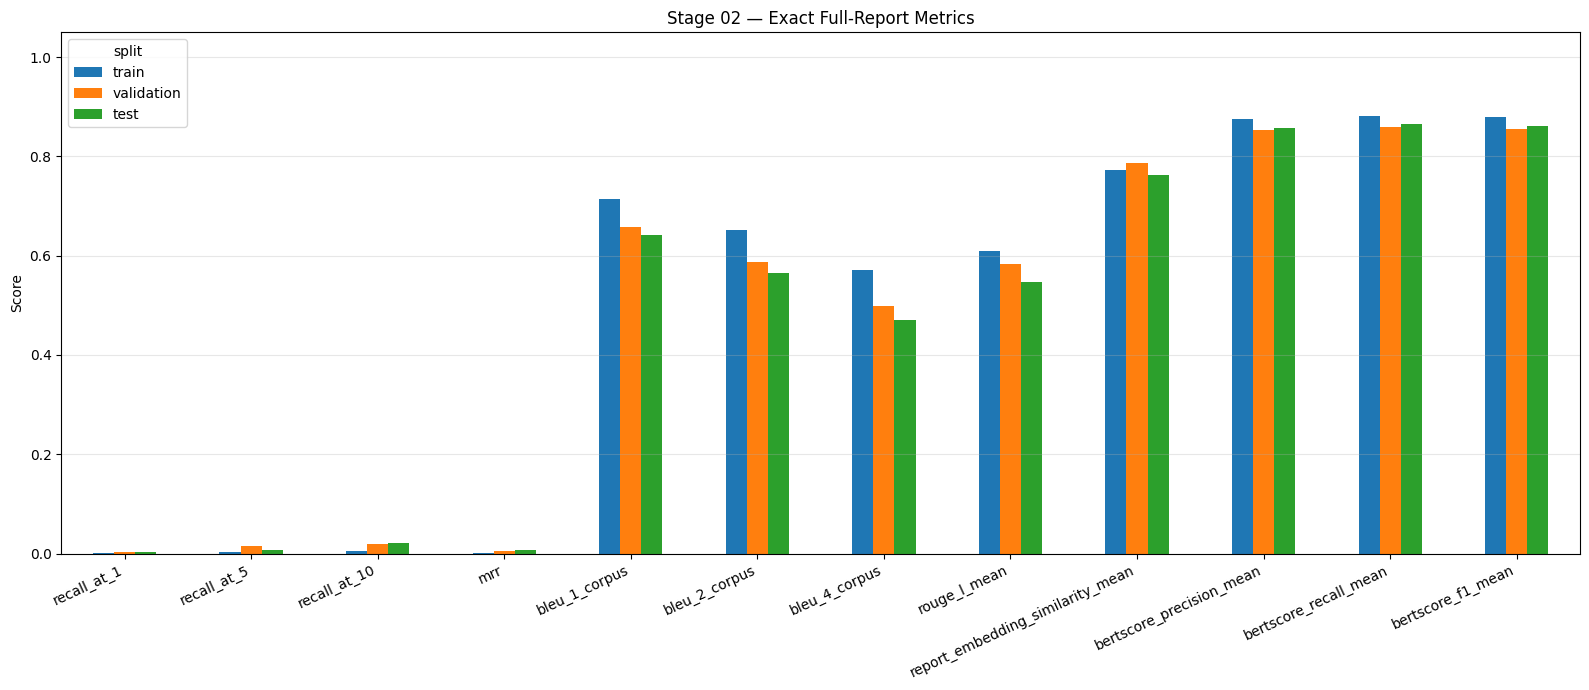

Dashboard saved: /content/drive/MyDrive/ViMedPET_Colab/stage02_output/vimedpet_stage02_retrieval_outputs/stage02_exact_dashboard.png


In [16]:
# CELL 16 — Exact metric dashboard

import matplotlib.pyplot as plt

metric_columns = [
    "recall_at_1",
    "recall_at_5",
    "recall_at_10",
    "mrr",
    "bleu_1_corpus",
    "bleu_2_corpus",
    "bleu_4_corpus",
    "rouge_l_mean",
    "report_embedding_similarity_mean",
    "bertscore_precision_mean",
    "bertscore_recall_mean",
    "bertscore_f1_mean",
]

dashboard_table = paired_metrics[
    ["split"] + metric_columns
].copy()

print(
    "===== EXACT FULL-REPORT METRICS ====="
)

display(
    dashboard_table.style.format({
        column: "{:.6f}"
        for column in metric_columns
    })
)

plot_df = (
    dashboard_table
    .set_index("split")
    .T
)

axis = plot_df.plot(
    kind="bar",
    figsize=(16, 7),
)

axis.set_title(
    "Stage 02 — Exact Full-Report Metrics"
)

axis.set_ylabel("Score")
axis.set_ylim(0, 1.05)
axis.grid(axis="y", alpha=0.3)

plt.xticks(
    rotation=25,
    ha="right",
)

plt.tight_layout()

dashboard_path = (
    OUTPUT_ROOT
    / "stage02_exact_dashboard.png"
)

plt.savefig(
    dashboard_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print("Dashboard saved:", dashboard_path)

In [17]:
# CELL 17 — Final Stage02 Direct Review Dashboard
# Cell này cố ý hiển thị lại toàn bộ chỉ số chính để PM/user không cần mở từng file output riêng lẻ.
print("===== STAGE 02 DIRECT REVIEW DASHBOARD =====")

print("\n[1] PM Gate")
print(json.dumps(pm_gate, ensure_ascii=False, indent=2))

print("\n[2] Input audit")
print(json.dumps(input_audit, ensure_ascii=False, indent=2))

print("\n[3] Split count by case")
display(split_count_by_case)

print("\n[4] Split count by patient group")
display(split_count_by_patient)

print("\n[5] Patient overlap matrix")
display(overlap)

print("\n[6] Source_part distribution by split")
display(source_part_by_split)

print("\n[7] Section completeness by split")
display(section_completeness)

print("\n[8] Report word count by split")
display(report_word_count_by_split)

print("\n[9] SUV/FDG by split and source_part")
display(suv_fdg_by_split_source)

print("\n[10] Clinical keyword coverage by split")
kw_pivot = clinical_keyword_by_split.pivot(index="keyword", columns="split", values="count").fillna(0).astype(int).reset_index()
display(kw_pivot)

print("\n[11] Duplicate exact report hash audit")
print("duplicate_hash_groups:", len(duplicate_report_hash_audit))
display(duplicate_report_hash_audit.head(30))

print("\n[12] Full cache channel stats")
display(full_cache_channel_stats)

print("\n[13] Channel stats by split")
display(channel_stats_by_split)

print("\n[14] Channel stats by source_part")
display(channel_stats_by_source_part)

print("\n[15] Blank / near-blank image review")
blank_df = pd.DataFrame(blank_rows)
print("blank_or_near_blank_count:", len(blank_df))
display(blank_df.head(30))

print("\n[16] Same-split exact full-report retrieval metrics")
display(paired_metrics)

print("\n[17] Retrieval metrics by source_part")
display(retrieval_metrics_by_source)

print("\n[18] Retrieval failure cases, first 50")
print("failure_count_hit_at_5_false:", len(retrieval_failure_cases))
display(retrieval_failure_cases.head(50))

print("\n[19] Validation top-K retrieved train reports")
display(val_topk.head(30))

print("\n[20] Test top-K retrieved train reports")
display(test_topk.head(30))

print("\n[21] Stage02 interpretation notes")
interpretation_notes = pd.DataFrame([
    {"item": "Stage01 input", "interpretation": "Must be PASS and 2757 cache rows before trusting Stage02."},
    {"item": "Patient overlap", "interpretation": "Off-diagonal values must be 0 for no-leakage split."},
    {"item": "Same-split retrieval", "interpretation": "Exact image-to-text alignment sanity check with ground-truth case_id inside same split."},
    {"item": "Validation/test topK to train", "interpretation": "RAG evidence candidate retrieval only; not exact Recall because splits are disjoint."},
    {"item": "2.5D limitation", "interpretation": "CT central slice + PET MIP cannot prove 3D lesion localization or absolute SUV reasoning."},
    {"item": "SUV/FDG tables", "interpretation": "Use to judge whether clinical terms and quantitative PET signals are balanced across splits/source_part."},
    {"item": "Channel stats", "interpretation": "Use to detect blank/low-contrast/cache normalization failures before training Stage03/Stage05."},
])
display(interpretation_notes)

===== STAGE 02 DIRECT REVIEW DASHBOARD =====

[1] PM Gate
{
  "stage": "02_retrieval_baseline",
  "pm_gate": "PASS",
  "reasons": {
    "stage01_pass": true,
    "row_count_ok": true,
    "patient_overlap_zero": true,
    "embeddings_finite": true,
    "faiss_index_exists": true,
    "full_report_coverage_100_percent": true
  }
}

[2] Input audit
{
  "stage": "02_retrieval_input_audit",
  "stage01_handle": "dngtrnphmtunse183674/00-01-cache-streaming",
  "stage02_source_handle": "tundng111/02-2-5d-pet-ct-retrieval-baseline",
  "cache_meta_path": "/content/drive/MyDrive/ViMedPET_Colab/stage01_output/vimedpet_q1_outputs/01_cache/q1_cache_meta.json",
  "manifest_path": "/content/drive/MyDrive/ViMedPET_Colab/stage01_output/vimedpet_q1_outputs/01_cache/q1_clean_manifest_for_cache.csv",
  "cache_index_path": "/content/drive/MyDrive/ViMedPET_Colab/stage01_output/vimedpet_q1_outputs/01_cache/q1_cache_index.csv",
  "memmap_path": "/content/drive/MyDrive/ViMedPET_Colab/stage01_output/vimedpet_q1_

,clean_split,n_cases
0,train,1930
1,validation,414
2,test,413



[4] Split count by patient group


,clean_split,n_patient_groups
0,train,1900
1,validation,414
2,test,413



[5] Patient overlap matrix


...

,query_split,query_case_id,query_source_part,query_report,rank_position,retrieved_case_id,retrieved_source_part,score,retrieved_report,retrieved_report_preview
0,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,1,4c7853acaf97,PETCT_2023_1,0.019459,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
1,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,2,cac459874261,PETCT_2019,0.013137,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh giảm tỉ trọ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh giảm tỉ trọ...
2,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,3,8a30316ad4fb,PETCT_2023_1,0.010366,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...
3,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,4,012834d5a0a7,PETCT_2018,0.010023,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
4,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,5,3e597d4aef20,PETCT_2023_2,0.008333,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
5,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,6,875f1b9a1ce9,PETCT_2023_1,0.008028,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tăng tỷ trọ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tăng tỷ trọ...
6,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,7,f4a2c30fba8f,PETCT_2019,0.002687,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...
7,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,8,dd502779143b,PETCT_2023_2,0.002110,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...
8,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,9,3cbe601e9ae8,PETCT_2023_1,-0.000279,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
9,validation,c1f034a8c785,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,10,0879d1c6404b,PETCT_2023_2,-0.001260,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh giảm tỷ trọ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh giảm tỷ trọ...



[20] Test top-K retrieved train reports


,query_split,query_case_id,query_source_part,query_report,rank_position,retrieved_case_id,retrieved_source_part,score,retrieved_report,retrieved_report_preview
0,test,8a00f68dbed3,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,1,4c7853acaf97,PETCT_2023_1,0.018040,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
1,test,8a00f68dbed3,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,2,cac459874261,PETCT_2019,0.013282,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh giảm tỉ trọ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh giảm tỉ trọ...
2,test,8a00f68dbed3,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,3,875f1b9a1ce9,PETCT_2023_1,0.012231,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tăng tỷ trọ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tăng tỷ trọ...
3,test,8a00f68dbed3,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,4,012834d5a0a7,PETCT_2018,0.009389,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
4,test,8a00f68dbed3,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,5,8a30316ad4fb,PETCT_2023_1,0.009330,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...
5,test,8a00f68dbed3,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,6,dd502779143b,PETCT_2023_2,0.004104,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...
6,test,8a00f68dbed3,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,7,3e597d4aef20,PETCT_2023_2,0.003702,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
7,test,8a00f68dbed3,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,8,3cbe601e9ae8,PETCT_2023_1,0.000918,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
8,test,8a00f68dbed3,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,9,145d66835886,PETCT_2023_1,-0.000395,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...
9,test,8a00f68dbed3,PETCT_2017,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh bắt xạ theo...,10,f4a2c30fba8f,PETCT_2019,-0.002378,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...,MÔ TẢ HÌNH ẢNH: Đầu - cổ: Hình ảnh tổn thương ...



[21] Stage02 interpretation notes


,item,interpretation
0,Stage01 input,Must be PASS and 2757 cache rows before trusti...
1,Patient overlap,Off-diagonal values must be 0 for no-leakage s...
2,Same-split retrieval,Exact image-to-text alignment sanity check wit...
3,Validation/test topK to train,RAG evidence candidate retrieval only; not exa...
4,2.5D limitation,CT central slice + PET MIP cannot prove 3D les...
5,SUV/FDG tables,Use to judge whether clinical terms and quanti...
6,Channel stats,Use to detect blank/low-contrast/cache normali...


In [18]:
# CELL 18 — Validate outputs and create downloadable ZIP

required_outputs = [
    TABLE_DIR
    / "reports_by_case_id.csv",
    TABLE_DIR
    / "reports_by_case_id.parquet",
    TABLE_DIR
    / "retrieval_detail_exact.csv",
    TABLE_DIR
    / "retrieval_detail_exact.parquet",
    OUTPUT_ROOT
    / "validation_topk_retrieved_exact.csv",
    OUTPUT_ROOT
    / "validation_topk_retrieved_exact.parquet",
    OUTPUT_ROOT
    / "test_topk_retrieved_exact.csv",
    OUTPUT_ROOT
    / "test_topk_retrieved_exact.parquet",
    OUTPUT_ROOT
    / "retrieval_metrics.json",
    OUTPUT_ROOT
    / "retrieval_metrics_summary.csv",
    OUTPUT_ROOT
    / "retrieval_pm_gate.json",
    OUTPUT_ROOT
    / "stage02_exact_dashboard.png",
    INDEX_DIR
    / "faiss_train_text.index",
]

missing_outputs = [
    str(path)
    for path in required_outputs
    if not path.exists()
]

if missing_outputs:
    raise FileNotFoundError(
        "Stage 02 finished but required "
        "output files are missing:\n"
        + "\n".join(missing_outputs)
    )

print("===== STAGE 02 OUTPUT FILES =====")

for path in sorted(
    OUTPUT_ROOT.rglob("*")
):
    if path.is_file():
        print(
            f"{path}  "
            f"{path.stat().st_size:,} bytes"
        )

zip_base = (
    STAGE2_ROOT
    / "vimedpet_stage02_exact_outputs"
)

zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=str(OUTPUT_ROOT),
)

print("\n✅ ZIP created:", zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print(
        "Không tự tải được. "
        "File ZIP nằm tại:",
        zip_path,
    )

===== STAGE 02 OUTPUT FILES =====
/content/drive/MyDrive/ViMedPET_Colab/stage02_output/vimedpet_stage02_retrieval_outputs/embeddings/test_image_emb.npy  110,812 bytes
/content/drive/MyDrive/ViMedPET_Colab/stage02_output/vimedpet_stage02_retrieval_outputs/embeddings/test_text_emb.npy  634,496 bytes
/content/drive/MyDrive/ViMedPET_Colab/stage02_output/vimedpet_stage02_retrieval_outputs/embeddings/train_image_emb.npy  517,368 bytes
/content/drive/MyDrive/ViMedPET_Colab/stage02_output/vimedpet_stage02_retrieval_outputs/embeddings/train_text_emb.npy  2,964,608 bytes
/content/drive/MyDrive/ViMedPET_Colab/stage02_output/vimedpet_stage02_retrieval_outputs/embeddings/validation_image_emb.npy  111,080 bytes
/content/drive/MyDrive/ViMedPET_Colab/stage02_output/vimedpet_stage02_retrieval_outputs/embeddings/validation_text_emb.npy  636,032 bytes
/content/drive/MyDrive/ViMedPET_Colab/stage02_output/vimedpet_stage02_retrieval_outputs/indices/faiss_train_text.index  2,964,525 bytes
/content/drive/MyDr

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>